<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Fseminario/seminario/urban_fire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Instala dependências
!pip install datasets tensorflow scikit-learn pillow

In [3]:
from datasets import load_dataset

# Carregar dataset do HuggingFace
dataset = load_dataset(
    path='incrisvel/urban-fire-identification'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/804 [00:00<?, ?it/s]

In [4]:
# Separar deterministicamente amostras de treino e teste
split_dataset = dataset['train'].train_test_split(
    test_size=0.2,
    stratify_by_column='label',
    seed=1
)

train_data = split_dataset['train']
test_data = split_dataset['test']

# Mostrar estrutura do dataset
split_dataset
split_dataset['train']

Dataset({
    features: ['image', 'label'],
    num_rows: 643
})

In [5]:
from tensorflow.keras.applications import MobileNetV2, InceptionV3, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# Carregar CNN pré-treinada
mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

inception = InceptionV3(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(299, 299, 3)
)

resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

In [6]:
CLASS_NAMES = dataset['train'].features['label'].names

# Estruturar dados armazenado para cada modelo
models = {
    'MobileNetV2': {
        'feature_extractor': mobilenet,
        'image_size': (224, 224),
        'preprocess': mobilenet_preprocess
    },
    'InceptionV3': {
        'feature_extractor': inception,
        'image_size': (299, 299),
        'preprocess': inception_preprocess
    },
    'ResNet50': {
        'feature_extractor': resnet,
        'image_size': (224, 224),
        'preprocess': resnet_preprocess
    }
}

In [7]:
from tensorflow.keras.preprocessing.image import img_to_array
import numpy as np

# Preparar imagens
def preprocess_images(model_name, dataset):
    images = []
    labels = []

    for sample in dataset:
        image = sample['image']

        # Converter para RGB por garantia
        image = image.convert('RGB')

        # Redimensionar imagens para mesmo tamanho
        image = image.resize(models[model_name]['image_size'])

        # Converter imagem para um ndarray
        image = img_to_array(image)

        images.append(image)
        labels.append(sample['label'])

    images = np.array(images)
    labels = np.array(labels)

    # Preprocessamento
    images = models[model_name]['preprocess'](images)

    return images, labels


# Extrair embeddings com CNN pré-treinada
def extract_features(model_name, dataset):

    # Extrair embeddings
    features = models[model_name]['feature_extractor'].predict(
        dataset,
        verbose=0,
        batch_size=32,
    )

    return features

In [8]:
# Armazenar imagens preprocessadas
for model_name, data in models.items():
    train_images, train_labels = preprocess_images(
        model_name,
        train_data
    )

    test_images, test_labels = preprocess_images(
        model_name,
        test_data
    )

    data['train_images'] = train_images
    data['train_labels'] = train_labels

    data['test_images'] = test_images
    data['test_labels'] = test_labels

In [9]:
import time


# Extrair features do modelo pré-treinado
for model_name, data in models.items():
    start = time.perf_counter()

    X_train = extract_features(
        model_name,
        data['train_images'],
    )

    X_test = extract_features(
        model_name,
        data['test_images']
    )

    end = time.perf_counter()

    data['embeddings'] = {
        'X_train': X_train,
        'X_test': X_test
    }

    # Coletar tempo de extração de features
    data['feature_extraction_time'] = end - start

In [10]:
from sklearn.preprocessing import StandardScaler

# Normalização dos embeddings para SVM
for model_name, data in models.items():
    embeddings = data['embeddings']
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(embeddings['X_train'])

    X_test_scaled = scaler.transform(embeddings['X_test'])

    embeddings['X_train'] = X_train_scaled
    embeddings['X_test'] = X_test_scaled

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'kernel': ['poly', 'sigmoid', 'rbf']
}

# Encontrar melhores parâmetros para SVM
for model_name, data in models.items():
    embeddings = data['embeddings']
    X_train, y_train = embeddings['X_train'], data['train_labels']

    grid = GridSearchCV(
        SVC(),
        param_grid,
        cv=5,
        scoring='accuracy'
    )

    grid.fit(X_train, y_train)

    data['best_params_svm'] = grid.best_params_

In [12]:
for model_name, data in models.items():
    print(f'Melhores parâmetros para SVM com {model_name}:', data['best_params_svm'])

Melhores parâmetros para SVM com MobileNetV2: {'C': 10, 'kernel': 'sigmoid'}
Melhores parâmetros para SVM com InceptionV3: {'C': 10, 'kernel': 'sigmoid'}
Melhores parâmetros para SVM com ResNet50: {'C': 1, 'kernel': 'sigmoid'}


In [13]:
# Treinar modelo com o melhor SVM
for model_name, data in models.items():
    best_params = data['best_params_svm']
    embeddings = data['embeddings']
    X_train, y_train = embeddings['X_train'], data['train_labels']

    start = time.perf_counter()

    svm = SVC(
        kernel=best_params['kernel'],
        C=best_params['C'],
        gamma='scale'
    )

    svm.fit(X_train, y_train)

    end = time.perf_counter()

    data['model_svm'] = svm
    data['svm_training_time'] = end - start

In [14]:
# Predições dos modelos
for model_name, data in models.items():
    svm = data['model_svm']

    y_pred = svm.predict(data['embeddings']['X_test'])

    data['predictions_svm'] = y_pred

    data['total_svm_time'] = (
        data['feature_extraction_time'] + data['svm_training_time']
    )

============================ MobileNetV2 ============================

Acurácia: 0.98

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       0.95      1.00      0.98        80
                 urban_fire       1.00      0.95      0.97        81

                   accuracy                           0.98       161
                  macro avg       0.98      0.98      0.98       161
               weighted avg       0.98      0.98      0.98       161


Matriz de confusão:


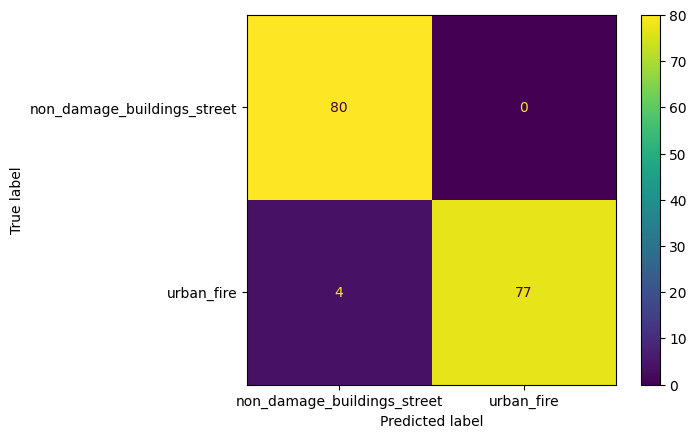

Tempo para extrair embeddings: 24.08s

Tempo de extração + treino: 24.11s

============================ InceptionV3 ============================

Acurácia: 0.98

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       0.99      0.96      0.97        80
                 urban_fire       0.96      0.99      0.98        81

                   accuracy                           0.98       161
                  macro avg       0.98      0.98      0.98       161
               weighted avg       0.98      0.98      0.98       161


Matriz de confusão:


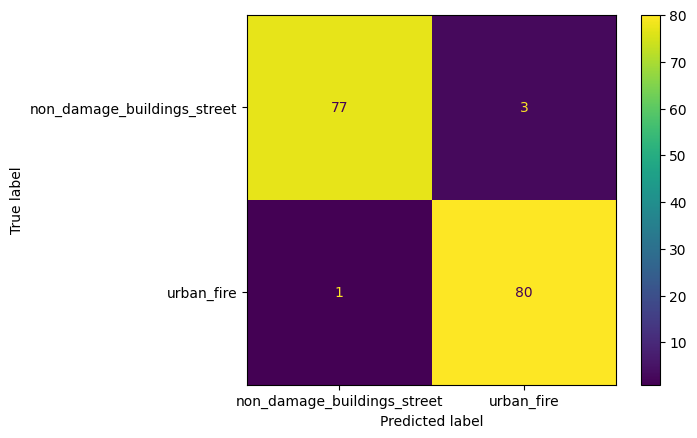

Tempo para extrair embeddings: 130.75s

Tempo de extração + treino: 130.78s

============================ ResNet50 ============================

Acurácia: 1.00

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       1.00      1.00      1.00        80
                 urban_fire       1.00      1.00      1.00        81

                   accuracy                           1.00       161
                  macro avg       1.00      1.00      1.00       161
               weighted avg       1.00      1.00      1.00       161


Matriz de confusão:


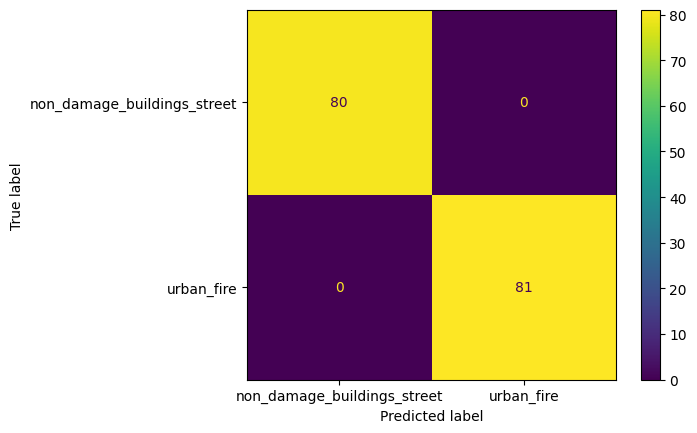

Tempo para extrair embeddings: 103.38s

Tempo de extração + treino: 103.44s



In [15]:
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Métricas de análise (CNN + SVM)
for model_name, data in models.items():
    print(f'{'=' * 28} {model_name} {'=' * 28}')

    y_test = data['test_labels']
    y_pred_svm = data['predictions_svm']

    print(f'\nAcurácia: {accuracy_score(y_test, y_pred_svm):.2f}')

    print('\nRelatório da classificação:')
    print(classification_report(
        y_true=y_test,
        y_pred=y_pred_svm,
        target_names=CLASS_NAMES
    ))

    print(f'\nMatriz de confusão:')
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true=y_test,
        y_pred=y_pred_svm,
        display_labels=CLASS_NAMES
    )

    disp.ax_.grid(False)
    plt.show()

    print(f'Tempo para extrair embeddings: {data['feature_extraction_time']:.2f}s\n')
    print(f'Tempo de extração + treino: {data['total_svm_time']:.2f}s\n')

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def create_classifier(feature_extractor):
    # Congelar a CNN pré-treinada
    feature_extractor.trainable = False

    # Adicionar camadas densas
    classifier = Sequential([
        feature_extractor,
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    classifier.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return classifier

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

for model_name, data in models.items():
    start = time.perf_counter()

    # Criar modelo com camadas densas para classificação
    cnn = create_classifier(
        data['feature_extractor']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
      restore_best_weights=True
    )

    history = cnn.fit(
        data['train_images'],
        data['train_labels'],
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    end = time.perf_counter()

    data['model_cnn'] = cnn
    data['cnn_history'] = history
    data['cnn_training_time'] = end - start

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8930 - loss: 0.2161 - val_accuracy: 0.9845 - val_loss: 0.0640
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 918ms/step - accuracy: 0.9825 - loss: 0.0576 - val_accuracy: 0.9922 - val_loss: 0.0203
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9961 - loss: 0.0237 - val_accuracy: 1.0000 - val_loss: 0.0163
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 935ms/step - accuracy: 0.9961 - loss: 0.0141 - val_accuracy: 0.9922 - val_loss: 0.0156
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9981 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 0.0144
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.9922 - val_loss: 0.0152
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9981 - loss: 0.0077 - val_accuracy: 0.9922 - val_loss: 0.0128
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.9922 - val

In [18]:
for model_name, data in models.items():

    y_prob = data['model_cnn'].predict(
        data['test_images'],
        verbose=0
    )

    y_pred = (
        y_prob > 0.5
    ).astype(int).flatten()

    data['predictions_cnn'] = y_pred

============================ MobileNetV2 ============================

Acurácia: 0.99

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       0.99      1.00      0.99        80
                 urban_fire       1.00      0.99      0.99        81

                   accuracy                           0.99       161
                  macro avg       0.99      0.99      0.99       161
               weighted avg       0.99      0.99      0.99       161


Matriz de confusão:


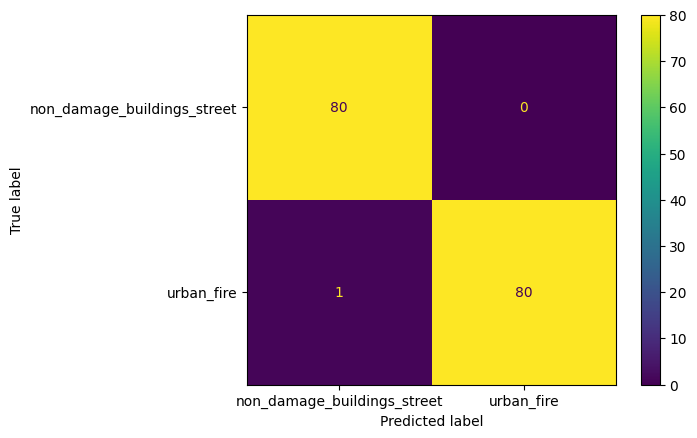

Tempo de treino: 214.58s

============================ InceptionV3 ============================

Acurácia: 0.99

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       1.00      0.99      0.99        80
                 urban_fire       0.99      1.00      0.99        81

                   accuracy                           0.99       161
                  macro avg       0.99      0.99      0.99       161
               weighted avg       0.99      0.99      0.99       161


Matriz de confusão:


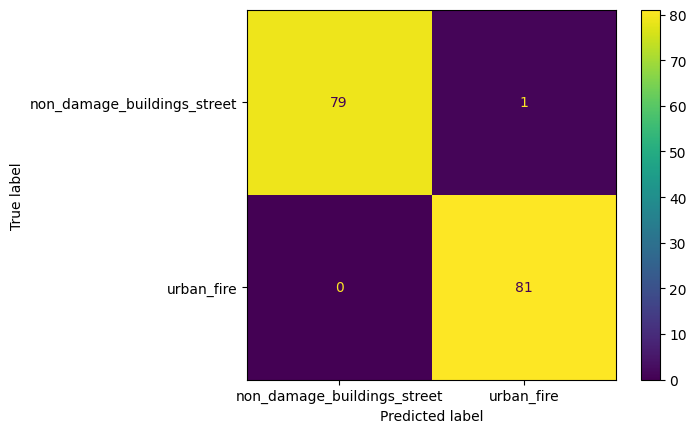

Tempo de treino: 1258.58s

============================ ResNet50 ============================

Acurácia: 0.98

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       1.00      0.95      0.97        80
                 urban_fire       0.95      1.00      0.98        81

                   accuracy                           0.98       161
                  macro avg       0.98      0.97      0.98       161
               weighted avg       0.98      0.98      0.98       161


Matriz de confusão:


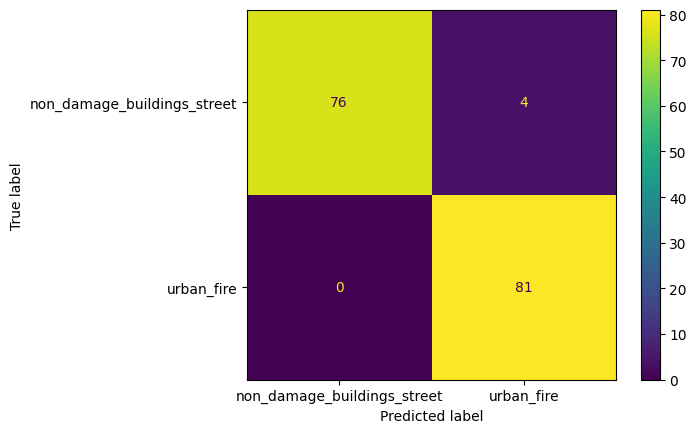

Tempo de treino: 327.13s



In [19]:
# Métricas de análise (CNN com camadas densas)
for model_name, data in models.items():
    print(f'{'=' * 28} {model_name} {'=' * 28}')

    y_test = data['test_labels']
    y_pred_cnn = data['predictions_cnn']

    print(f'\nAcurácia: {accuracy_score(y_test, y_pred_cnn):.2f}')

    print('\nRelatório da classificação:')
    print(classification_report(
        y_true=y_test,
        y_pred=y_pred_cnn,
        target_names=CLASS_NAMES
    ))

    print(f'\nMatriz de confusão:')
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true=y_test,
        y_pred=y_pred_cnn,
        display_labels=CLASS_NAMES
    )
    disp.ax_.grid(False)
    plt.show()

    print(f'Tempo de treino: {data['cnn_training_time']:.2f}s\n')

